# Topic prevalence scatter — manual labels

Compares topic prevalence (% of each outlet's corpus) against Tagesschau for every alternative outlet.

Two levels:
- **Cluster level** — `Manual Cluster Label` (~19 labels per subplot)
- **Topic level** — `Manual Topic Label` (~73 labels per subplot)

Data: `02_TopicModeling/outputs/03_new_topic_assignments.csv`

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from adjustText import adjust_text

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT = Path.cwd()
if ROOT.name != "Thesis":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "02_TopicModeling" / "outputs" / "03_new_topic_assignments.csv"

FIG_BASE = ROOT / "02_TopicModeling" / "outputs" / "figures" / "prevalence_scatter"
(FIG_BASE / "cluster_level").mkdir(parents=True, exist_ok=True)
(FIG_BASE / "topic_level").mkdir(parents=True, exist_ok=True)

# ── load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw = df_raw.dropna(subset=["source", "Manual Cluster Label", "Manual Topic Label"])
df_raw = df_raw[df_raw["Manual Cluster Label"].str.strip() != ""]
df_raw = df_raw[df_raw["Manual Topic Label"].str.strip() != ""]

# Strip stray trailing # from label columns (e.g. "Green Politics & Woke Culture#")
for _col in ["Manual Cluster Label", "Manual Topic Label"]:
    df_raw[_col] = df_raw[_col].str.rstrip("#").str.strip()

# ── outlets ───────────────────────────────────────────────────────────────────
REFERENCE   = "Tagesschau"
ALT_ORDER   = ["RT", "Antispiegel", "Compact", "Deutschlandkurier", "Nius", "Tichys Einblick"]
ALL_OUTLETS = [REFERENCE] + ALT_ORDER

OUTLET_COLOR = {
    "RT":                 "#E07B2A",
    "Antispiegel":        "#C0392B",
    "Compact":            "#8E44AD",
    "Deutschlandkurier":  "#2471A3",
    "Nius":               "#1ABC9C",
    "Tichys Einblick":    "#D4AC0D",
}
OUTLET_COLOR_LIGHT = {k: v + "55" for k, v in OUTLET_COLOR.items()}  # translucent unlabeled

# colors for labeled points: above-diagonal (outlet dominant) vs below-diagonal (Tagesschau dominant)
COLOR_ABOVE = "#C46F3A"   # warm orange — outlet over-represents
COLOR_BELOW = "#2E86C1"   # blue — Tagesschau over-represents
COLOR_NONE  = "#E8CBB8"   # light salmon — unlabeled

print("Rows loaded:", len(df_raw))
print("Outlets:", df_raw["source"].value_counts().to_dict())
print("Clusters:", df_raw["Manual Cluster Label"].nunique())
print("Topics:  ", df_raw["Manual Topic Label"].nunique())


Rows loaded: 19812
Outlets: {'Tagesschau': 6227, 'RT': 4441, 'Nius': 3182, 'Tichys Einblick': 2620, 'Deutschlandkurier': 1406, 'Compact': 1387, 'Antispiegel': 549}
Clusters: 18
Topics:   72


In [25]:
def compute_shares(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """
    For each (outlet, label) pair return share_pct = articles / total_outlet_articles * 100.
    Missing labels for an outlet are filled with 0.
    """
    label_universe = sorted(df[label_col].unique())

    frames = []
    for outlet in ALL_OUTLETS:
        sub = df[df["source"] == outlet]
        total = len(sub)
        counts = sub[label_col].value_counts()
        frame = pd.DataFrame({"label": label_universe})
        frame["outlet"] = outlet
        frame["article_count"] = frame["label"].map(counts).fillna(0).astype(int)
        frame["outlet_total"]  = total
        frame["share_pct"]     = np.where(total > 0, frame["article_count"] / total * 100, 0.0)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def build_comparison_df(shares: pd.DataFrame) -> pd.DataFrame:
    """
    Wide-form per (label, alt_outlet): tagesschau_share_pct, outlet_share_pct, relative_deviation.
    """
    ts = shares[shares["outlet"] == REFERENCE][["label", "share_pct"]].rename(
        columns={"share_pct": "tagesschau_share_pct"}
    )

    frames = []
    for outlet in ALT_ORDER:
        alt = shares[shares["outlet"] == outlet][["label", "share_pct"]].rename(
            columns={"share_pct": "outlet_share_pct"}
        )
        cmp = ts.merge(alt, on="label", how="left")
        cmp["outlet_share_pct"] = cmp["outlet_share_pct"].fillna(0.0)
        cmp["share_gap_pct"]       = cmp["outlet_share_pct"] - cmp["tagesschau_share_pct"]
        cmp["relative_deviation"]  = cmp["share_gap_pct"] / np.maximum(cmp["tagesschau_share_pct"], 0.1)
        cmp["combined_share_pct"]  = cmp["outlet_share_pct"] + cmp["tagesschau_share_pct"]
        cmp["outlet"]              = outlet
        frames.append(cmp)

    return pd.concat(frames, ignore_index=True)


def scan_thresholds(cmp: pd.DataFrame, target: int = 8) -> tuple[float, float, float, float]:
    """
    Asymmetric grid-search: separate thresholds for above-diagonal (outlet dominant)
    and below-diagonal (Tagesschau dominant).

    Above-diagonal: rel_dev can be >> 1 → search [0.8 … 2.5]
    Below-diagonal: rel_dev is mathematically capped at -1.0 → search [0.2 … 0.6]

    Each side targets `target` labeled dots per outlet independently.
    Returns (rel_above, sh_above, rel_below, sh_below).
    """
    # above-diagonal search
    above_rel_cands   = [0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
    above_share_cands = [1.0, 1.5, 2.0, 2.5, 3.0]
    best_penalty_ab, best_ab = float("inf"), (1.2, 2.0)
    for rel_t in above_rel_cands:
        for sh_t in above_share_cands:
            penalty = sum(
                abs(int(((cmp[cmp["outlet"] == o]["relative_deviation"] > rel_t) &
                          (cmp[cmp["outlet"] == o]["outlet_share_pct"] > sh_t)).sum()) - target)
                for o in ALT_ORDER
            )
            if penalty < best_penalty_ab:
                best_penalty_ab, best_ab = penalty, (rel_t, sh_t)

    # below-diagonal search (lower scale: max rel_dev ≈ -1.0)
    below_rel_cands   = [0.2, 0.3, 0.4, 0.5, 0.6]
    below_share_cands = [1.5, 2.0, 2.5, 3.0]
    best_penalty_bel, best_bel = float("inf"), (0.4, 2.0)
    for rel_t in below_rel_cands:
        for sh_t in below_share_cands:
            penalty = sum(
                abs(int(((cmp[cmp["outlet"] == o]["relative_deviation"] < -rel_t) &
                          (cmp[cmp["outlet"] == o]["tagesschau_share_pct"] > sh_t)).sum()) - target)
                for o in ALT_ORDER
            )
            if penalty < best_penalty_bel:
                best_penalty_bel, best_bel = penalty, (rel_t, sh_t)

    print(f"  Above-diag: rel_dev > {best_ab[0]},  outlet_share > {best_ab[1]}%  (penalty={best_penalty_ab})")
    print(f"  Below-diag: rel_dev < -{best_bel[0]}, ts_share    > {best_bel[1]}%  (penalty={best_penalty_bel})")
    return best_ab[0], best_ab[1], best_bel[0], best_bel[1]


def apply_labels(cmp: pd.DataFrame, rel_ab: float, sh_ab: float,
                 rel_bel: float, sh_bel: float) -> pd.DataFrame:
    cmp = cmp.copy()
    cmp["above_diag"] = (
        (cmp["relative_deviation"] > rel_ab) & (cmp["outlet_share_pct"] > sh_ab)
    )
    cmp["below_diag"] = (
        (cmp["relative_deviation"] < -rel_bel) & (cmp["tagesschau_share_pct"] > sh_bel)
    )
    cmp["should_label"] = cmp["above_diag"] | cmp["below_diag"]
    return cmp


def _style_ax(ax, axis_max):
    step = 1.0 if axis_max <= 6 else (2.0 if axis_max <= 12 else 5.0)
    ax.set_facecolor("white")
    ax.grid(True, color="#D9D9D9", alpha=0.30, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.set_axisbelow(True)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))


def plot_single(ax, outlet: str, cmp: pd.DataFrame, axis_max: float):
    sub = cmp[cmp["outlet"] == outlet].copy()
    unlabeled = sub[~sub["should_label"]]
    above     = sub[sub["above_diag"]]
    below     = sub[sub["below_diag"]]

    _style_ax(ax, axis_max)
    ax.plot([0, axis_max], [0, axis_max], linestyle=(0, (4, 4)), lw=1.0, color="#B5B5B5", zorder=1)

    if not unlabeled.empty:
        ax.scatter(unlabeled["tagesschau_share_pct"], unlabeled["outlet_share_pct"],
                   s=18, color=COLOR_NONE, alpha=0.55, linewidths=0, zorder=2)
    if not above.empty:
        ax.scatter(above["tagesschau_share_pct"], above["outlet_share_pct"],
                   s=22, color=COLOR_ABOVE, alpha=0.85, linewidths=0, zorder=3)
    if not below.empty:
        ax.scatter(below["tagesschau_share_pct"], below["outlet_share_pct"],
                   s=22, color=COLOR_BELOW, alpha=0.85, linewidths=0, zorder=3)

    # build text objects for all labeled points, then let adjustText push them apart
    labeled = pd.concat([above, below]).sort_values("combined_share_pct", ascending=False)
    texts = [
        ax.text(
            row["tagesschau_share_pct"],
            row["outlet_share_pct"],
            row["label"],
            fontsize=6.5,
            color="#1F1F1F",
            zorder=5,
        )
        for _, row in labeled.iterrows()
    ]
    if texts:
        adjust_text(
            texts,
            x=labeled["tagesschau_share_pct"].to_numpy(dtype=float),
            y=labeled["outlet_share_pct"].to_numpy(dtype=float),
            ax=ax,
            force_text=(0.6, 0.8),
            force_static=(0.4, 0.4),
            expand=(1.4, 1.6),
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6, alpha=0.7),
        )

    ax.set_title(outlet, fontsize=12, pad=8)


def plot_grid(cmp: pd.DataFrame, level_name: str, fig_dir: Path):
    axis_max = float(np.ceil(
        cmp[["tagesschau_share_pct", "outlet_share_pct"]].to_numpy().max() + 1.0
    ))

    # individual PDFs
    for outlet in ALT_ORDER:
        fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=150)
        plot_single(ax, outlet, cmp, axis_max)
        ax.set_xlabel("Tagesschau topic prevalence (%)")
        ax.set_ylabel("Outlet topic prevalence (%)")
        path = fig_dir / f"scatter_{outlet.lower().replace(' ', '_')}_vs_tagesschau.pdf"
        fig.savefig(path, bbox_inches="tight", dpi=300, facecolor="white")
        plt.close(fig)

    # 3×2 grid
    grid_fig, axes = plt.subplots(3, 2, figsize=(13, 16), dpi=150, sharex=True, sharey=True)
    for ax, outlet in zip(axes.flat, ALT_ORDER):
        plot_single(ax, outlet, cmp, axis_max)

    # shared legend
    handles = [
        Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_ABOVE, label="Outlet over-represents"),
        Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_BELOW, label="Tagesschau over-represents"),
        Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_NONE,  alpha=0.55, label="Not labeled"),
    ]
    grid_fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
                    ncol=3, fontsize=9, frameon=False)
    grid_fig.supxlabel("Tagesschau topic prevalence (%)", fontsize=12, y=0.05)
    grid_fig.supylabel("Outlet topic prevalence (%)",     fontsize=12, x=0.04)
    grid_fig.suptitle(f"Topic prevalence vs Tagesschau — {level_name}", fontsize=14, y=1.01)
    grid_fig.tight_layout(rect=(0.05, 0.08, 1.0, 1.0))

    grid_path = fig_dir / "scatter_all_outlets.pdf"
    grid_fig.savefig(grid_path, bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    plt.close(grid_fig)
    print(f"Saved grid to: {grid_path}")


## Cluster level

One dot per `Manual Cluster Label` (~19 labels). Larger deviations are expected here since
clusters aggregate many BERTopic sub-topics.

── Cluster level ──────────────────────────────────────────
Threshold scan:
  Above-diag: rel_dev > 0.8,  outlet_share > 1.0%  (penalty=14)
  Below-diag: rel_dev < -0.5, ts_share    > 1.5%  (penalty=7)
Labeled dots per outlet (above / below diagonal):
                   above_diag  below_diag
outlet                                   
Antispiegel                 3           9
Compact                     4           5
Deutschlandkurier           5           6
Nius                        4           5
RT                          2           6
Tichys Einblick             4           4


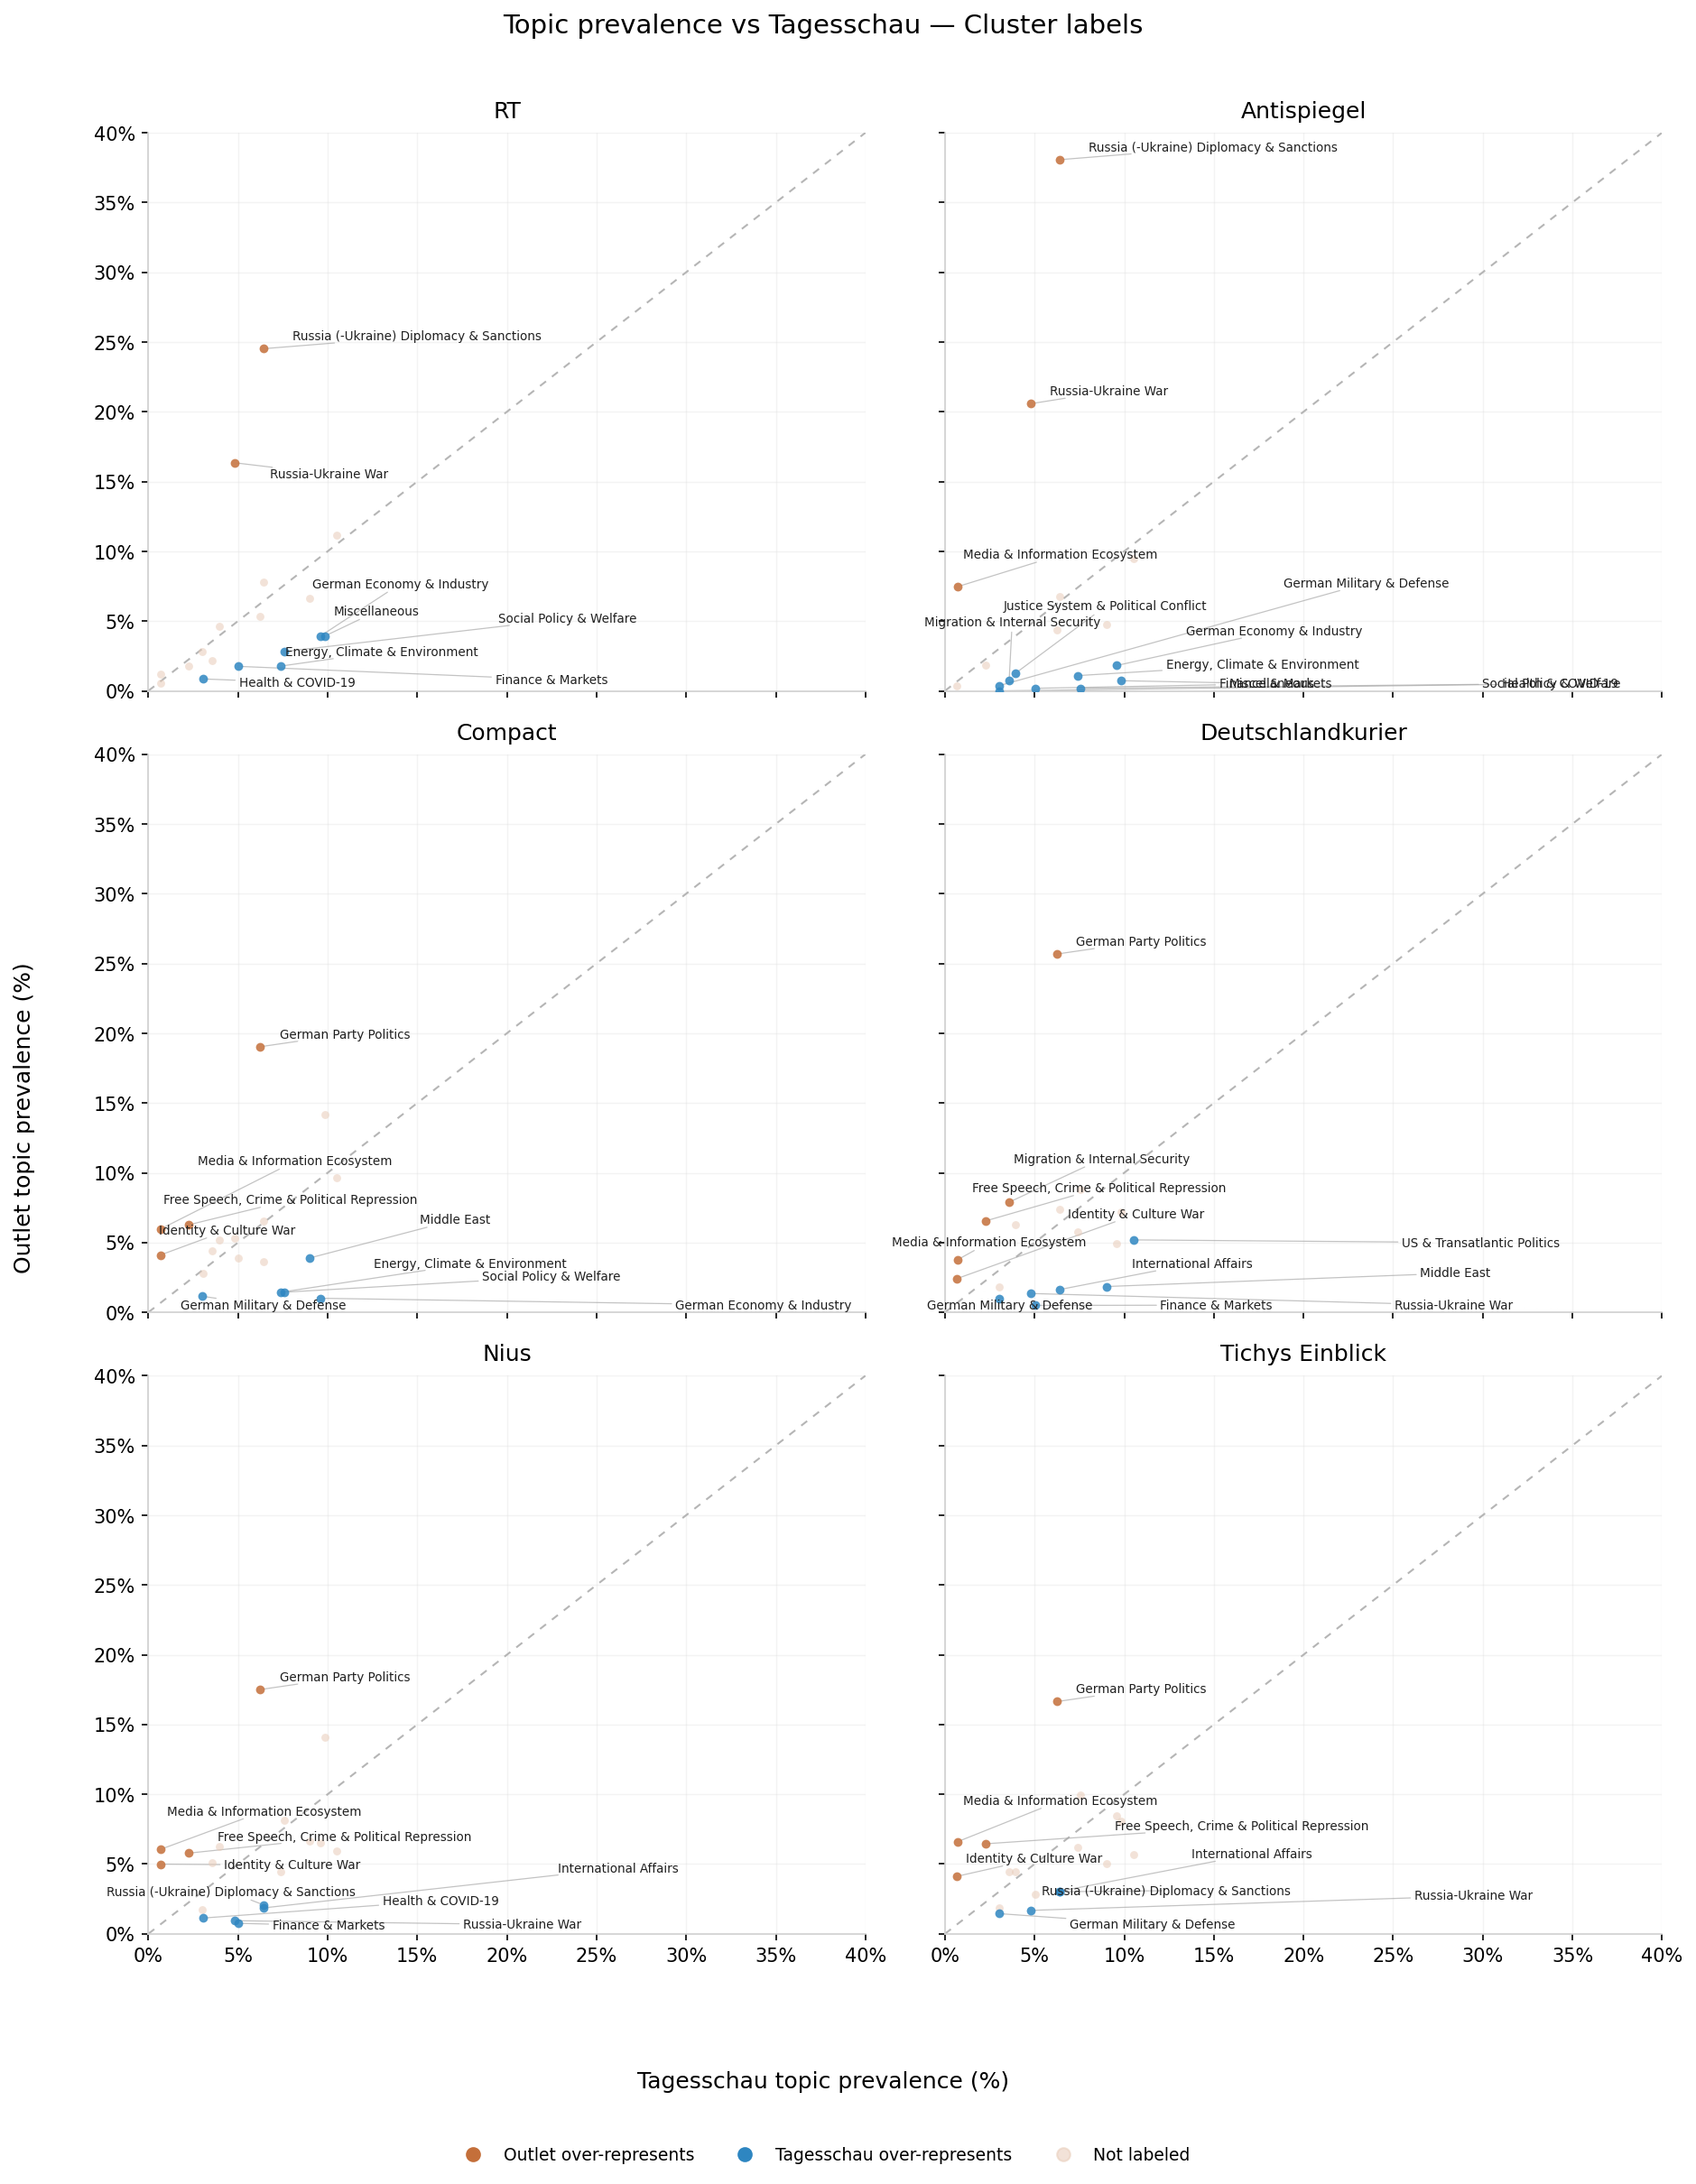

Saved grid to: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/cluster_level/scatter_all_outlets.pdf


In [26]:
print("── Cluster level ──────────────────────────────────────────")
cluster_shares = compute_shares(df_raw, "Manual Cluster Label")
cluster_cmp    = build_comparison_df(cluster_shares)

print("Threshold scan:")
rel_ab, sh_ab, rel_bel, sh_bel = scan_thresholds(cluster_cmp, target=6)
cluster_cmp = apply_labels(cluster_cmp, rel_ab, sh_ab, rel_bel, sh_bel)

labeled_n = cluster_cmp.groupby("outlet")[["above_diag","below_diag"]].sum()
print("Labeled dots per outlet (above / below diagonal):")
print(labeled_n.to_string())

plot_grid(cluster_cmp, "Cluster labels", FIG_BASE / "cluster_level")


## Topic level

One dot per `Manual Topic Label` (~73 labels). Subplots are more dense; the threshold scan
will pick a higher `share_threshold` to keep labels readable.

── Topic level ─────────────────────────────────────────────
Threshold scan:
  Above-diag: rel_dev > 0.8,  outlet_share > 3.0%  (penalty=5)
  Below-diag: rel_dev < -0.5, ts_share    > 2.0%  (penalty=2)
Labeled dots per outlet (above / below diagonal):
                   above_diag  below_diag
outlet                                   
Antispiegel                 6           6
Compact                     8           6
Deutschlandkurier           6           7
Nius                        7           6
RT                          5           5
Tichys Einblick             5           6


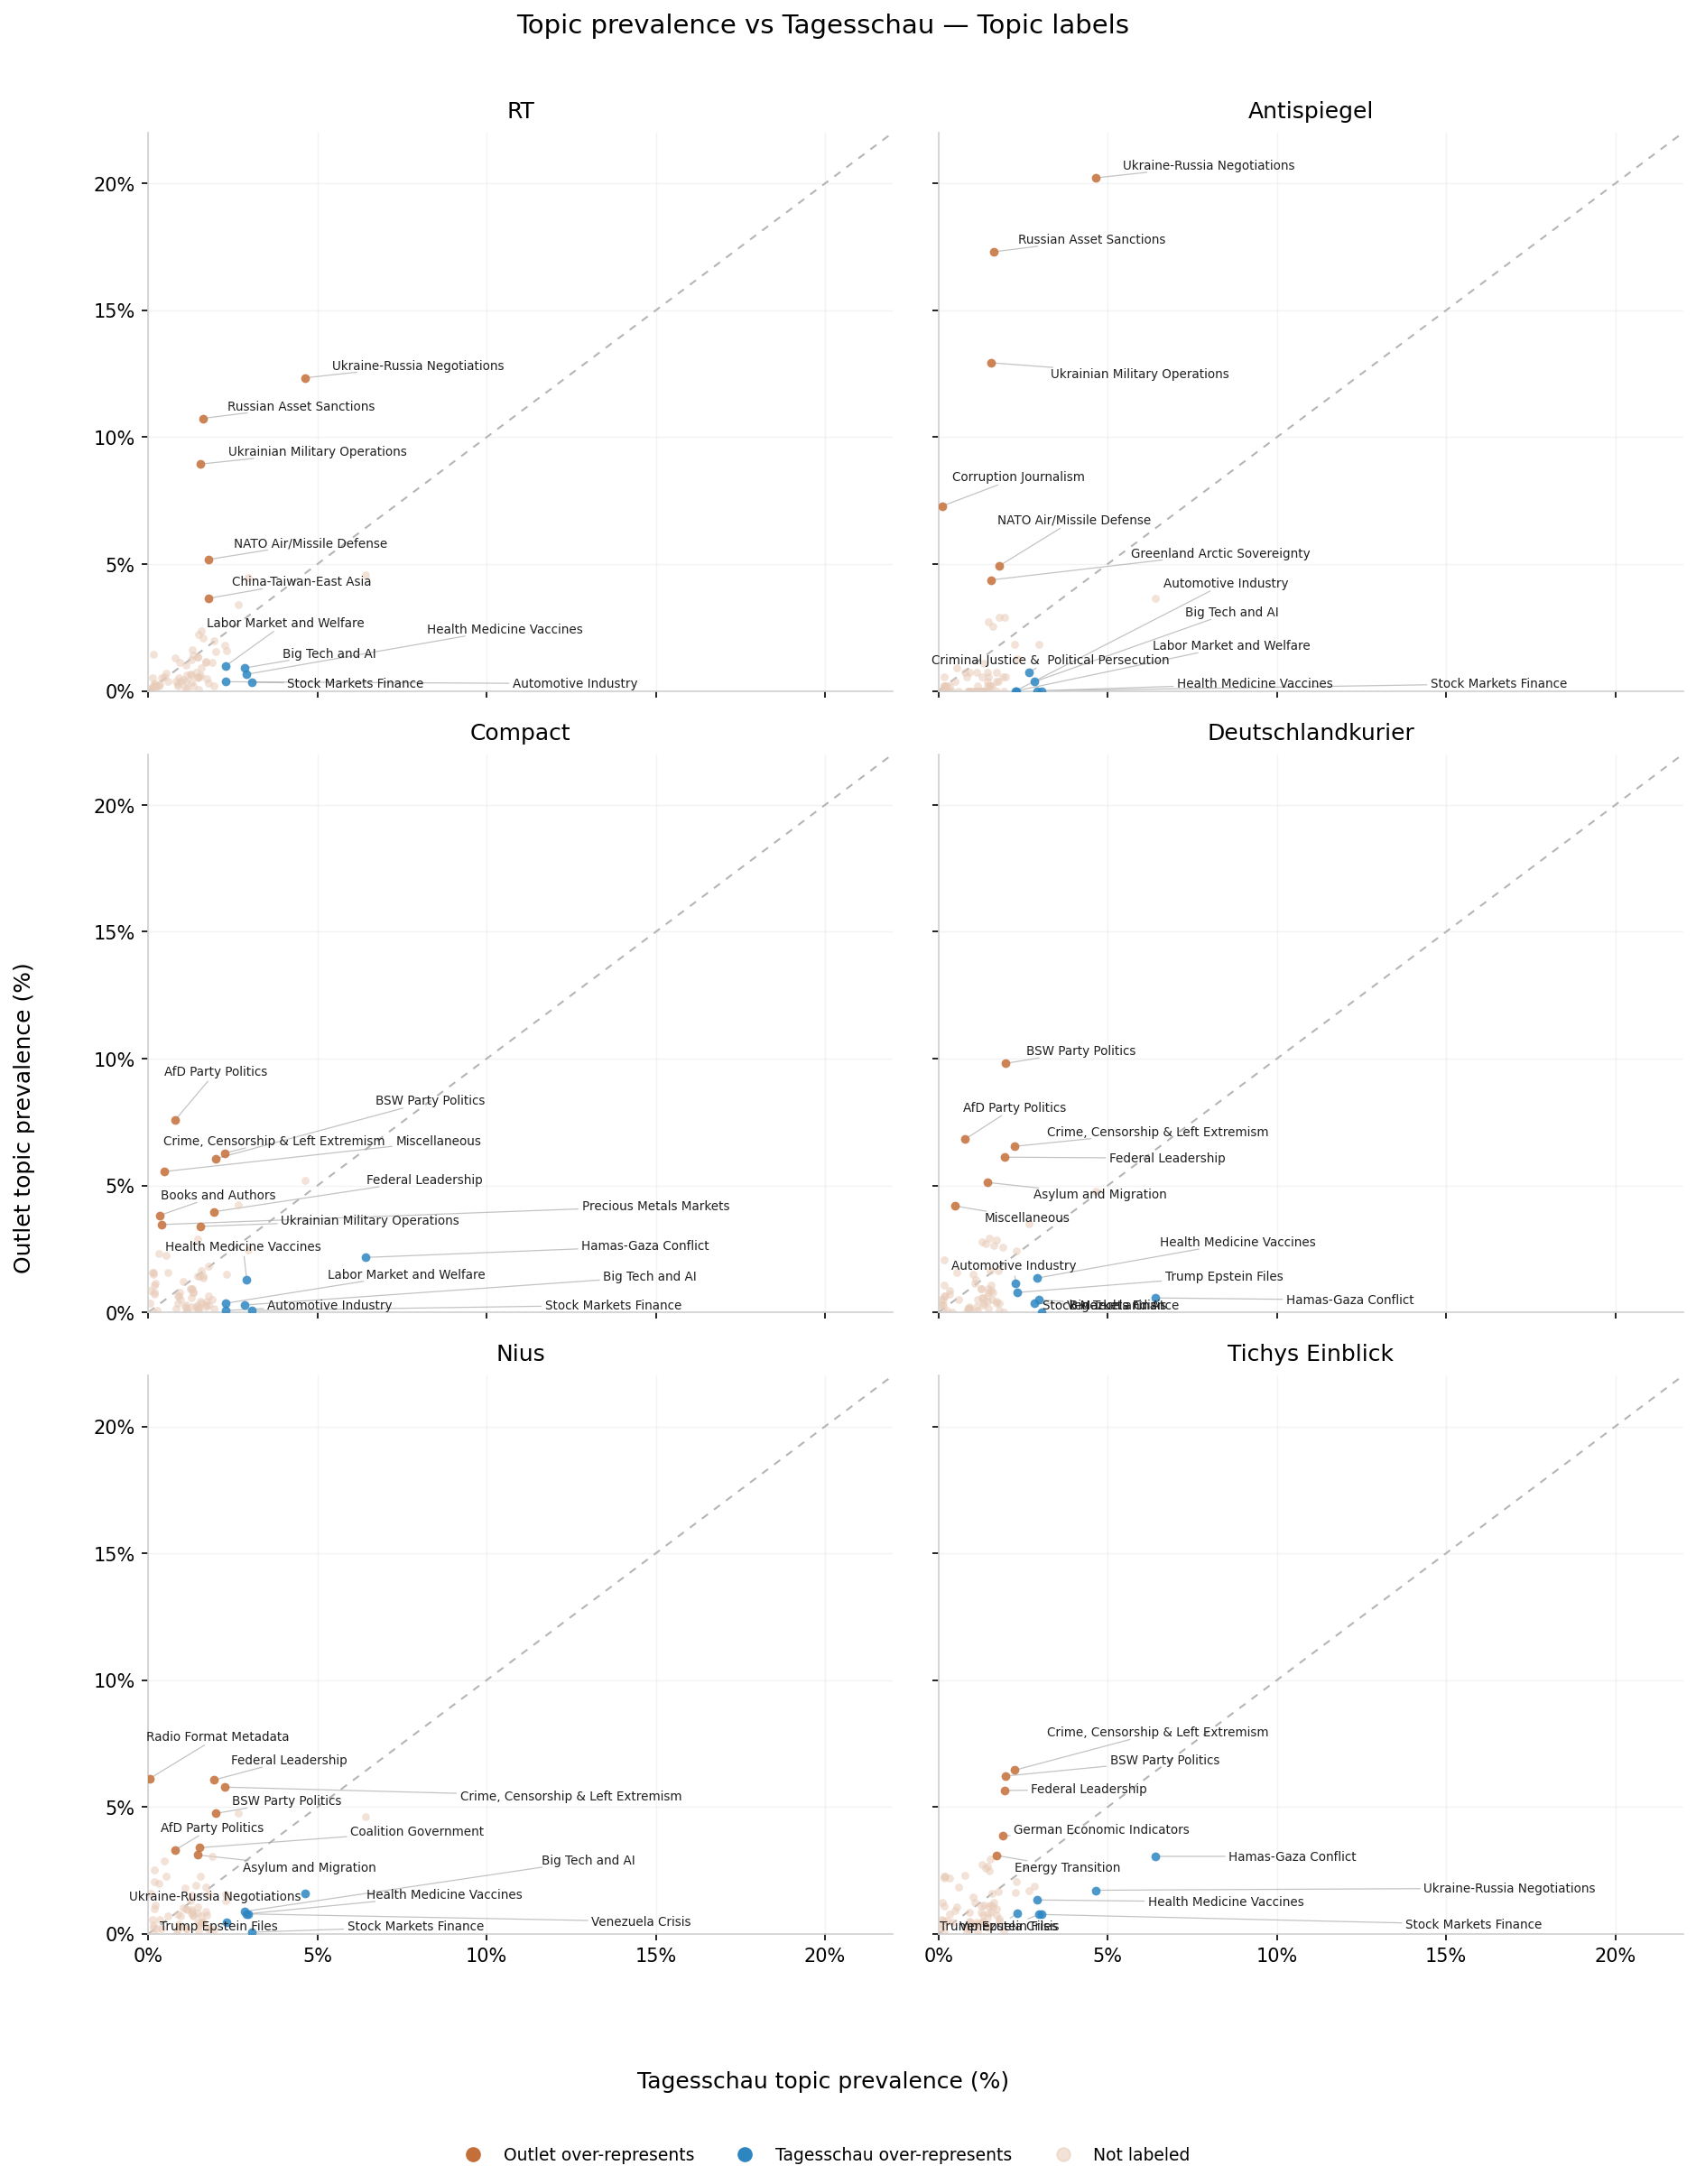

Saved grid to: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/topic_level/scatter_all_outlets.pdf


In [27]:
print("── Topic level ─────────────────────────────────────────────")
topic_shares = compute_shares(df_raw, "Manual Topic Label")
topic_cmp    = build_comparison_df(topic_shares)

print("Threshold scan:")
rel_ab, sh_ab, rel_bel, sh_bel = scan_thresholds(topic_cmp, target=6)
topic_cmp = apply_labels(topic_cmp, rel_ab, sh_ab, rel_bel, sh_bel)

labeled_n = topic_cmp.groupby("outlet")[["above_diag","below_diag"]].sum()
print("Labeled dots per outlet (above / below diagonal):")
print(labeled_n.to_string())

plot_grid(topic_cmp, "Topic labels", FIG_BASE / "topic_level")


## Tagesschau vs all alternative media combined

Single scatter plot per level: x = Tagesschau prevalence, y = pooled prevalence across all 6 alternative outlets together.

The pooled share is computed as `articles in topic across all alt outlets ÷ total alt-outlet articles`, so each outlet contributes proportionally to its corpus size.

── Combined: Cluster level ──────────────────────────────────
  Above-diag: rel_dev > 0.8,  alt_share  > 1.0%
  Below-diag: rel_dev < -0.2, ts_share  > 1.5%


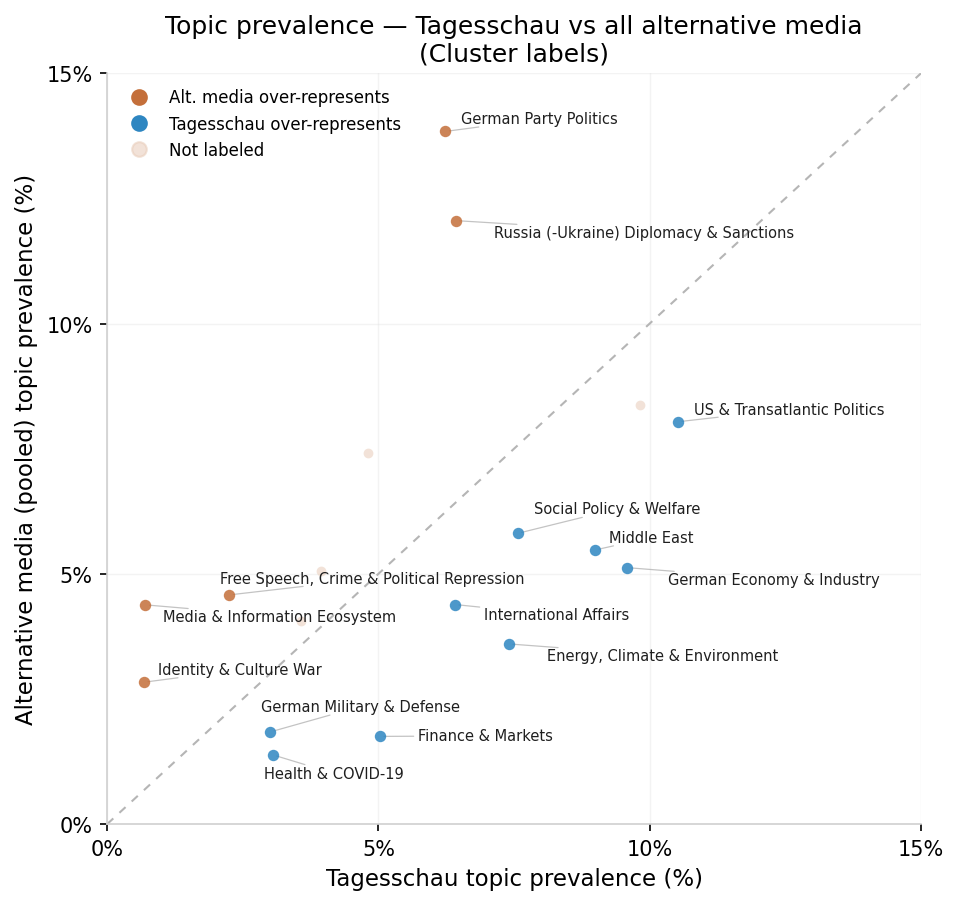

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/cluster_level/scatter_combined_vs_tagesschau.pdf

── Combined: Topic level ────────────────────────────────────
  Above-diag: rel_dev > 1.2,  alt_share  > 1.0%
  Below-diag: rel_dev < -0.2, ts_share  > 2.0%


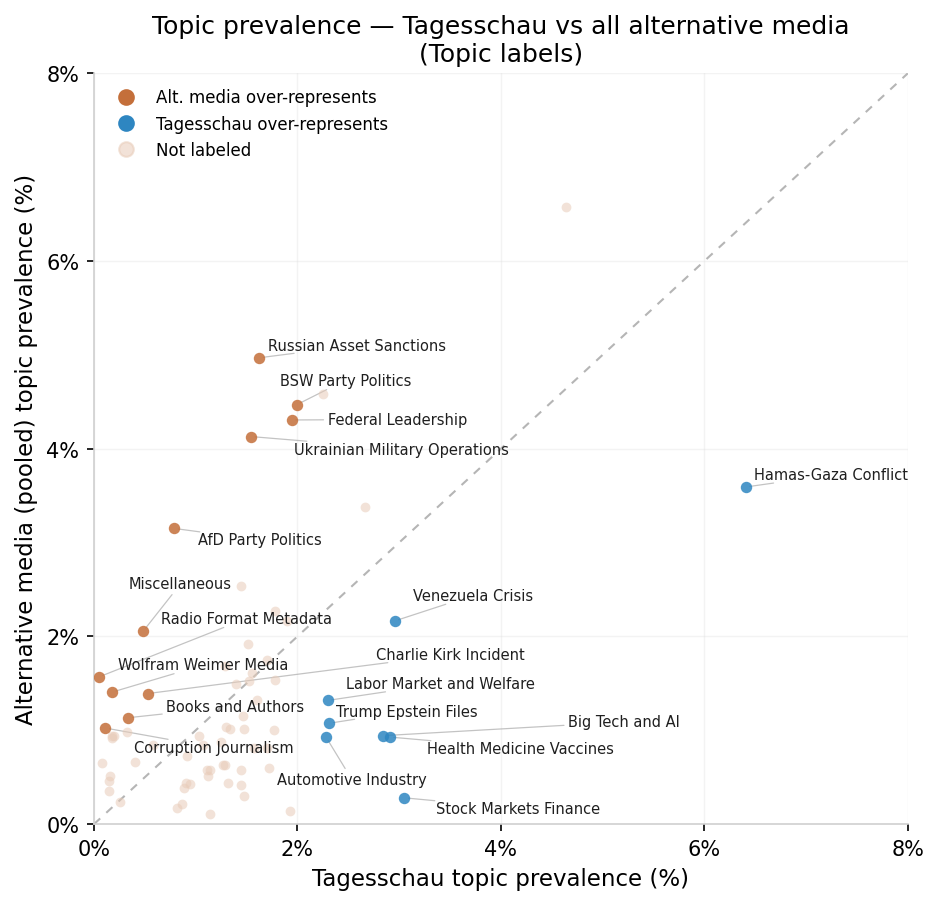

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/topic_level/scatter_combined_vs_tagesschau.pdf


In [28]:
def compute_combined_vs_tagesschau(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """
    Returns one row per label with:
      tagesschau_share_pct  — % of Tagesschau corpus
      alt_share_pct         — % of pooled alternative-media corpus
      relative_deviation    — (alt - ts) / max(ts, 0.1)
    """
    label_universe = sorted(df[label_col].unique())

    # Tagesschau
    ts_df  = df[df["source"] == REFERENCE]
    ts_tot = len(ts_df)
    ts_counts = ts_df[label_col].value_counts()

    # Alternative outlets pooled
    alt_df  = df[df["source"].isin(ALT_ORDER)]
    alt_tot = len(alt_df)
    alt_counts = alt_df[label_col].value_counts()

    rows = []
    for label in label_universe:
        ts_share  = ts_counts.get(label, 0) / ts_tot  * 100 if ts_tot  else 0.0
        alt_share = alt_counts.get(label, 0) / alt_tot * 100 if alt_tot else 0.0
        rel_dev   = (alt_share - ts_share) / max(ts_share, 0.1)
        rows.append({
            "label":                label,
            "tagesschau_share_pct": ts_share,
            "alt_share_pct":        alt_share,
            "relative_deviation":   rel_dev,
            "combined_share_pct":   ts_share + alt_share,
        })

    return pd.DataFrame(rows)


def scan_thresholds_combined(cmp: pd.DataFrame, target: int = 10) -> tuple[float, float, float, float]:
    """Same asymmetric grid-search as per-outlet, but for a single combined panel.
    Target 10 gives a readable density for the larger single-panel view."""
    above_rel_cands   = [0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
    above_share_cands = [1.0, 1.5, 2.0, 2.5, 3.0]
    below_rel_cands   = [0.2, 0.3, 0.4, 0.5, 0.6]
    below_share_cands = [1.5, 2.0, 2.5, 3.0]

    best_ab  = min(
        ((abs(int(((cmp["relative_deviation"] >  r) & (cmp["alt_share_pct"]        > s)).sum()) - target), r, s)
         for r in above_rel_cands for s in above_share_cands),
    )[1:]
    best_bel = min(
        ((abs(int(((cmp["relative_deviation"] < -r) & (cmp["tagesschau_share_pct"] > s)).sum()) - target), r, s)
         for r in below_rel_cands for s in below_share_cands),
    )[1:]

    print(f"  Above-diag: rel_dev > {best_ab[0]},  alt_share  > {best_ab[1]}%")
    print(f"  Below-diag: rel_dev < -{best_bel[0]}, ts_share  > {best_bel[1]}%")
    return best_ab[0], best_ab[1], best_bel[0], best_bel[1]


def plot_combined(cmp: pd.DataFrame, level_name: str, fig_dir: Path):
    rel_ab, sh_ab, rel_bel, sh_bel = scan_thresholds_combined(cmp)

    cmp = cmp.copy()
    cmp["above_diag"] = (cmp["relative_deviation"] >  rel_ab)  & (cmp["alt_share_pct"]        > sh_ab)
    cmp["below_diag"] = (cmp["relative_deviation"] < -rel_bel) & (cmp["tagesschau_share_pct"] > sh_bel)
    cmp["should_label"] = cmp["above_diag"] | cmp["below_diag"]

    axis_max = float(np.ceil(
        cmp[["tagesschau_share_pct", "alt_share_pct"]].to_numpy().max() + 1.0
    ))
    step = 1.0 if axis_max <= 6 else (2.0 if axis_max <= 12 else 5.0)

    fig, ax = plt.subplots(figsize=(7, 6.5), dpi=150)
    ax.set_facecolor("white")
    ax.grid(True, color="#D9D9D9", alpha=0.30, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.set_axisbelow(True)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

    ax.plot([0, axis_max], [0, axis_max], linestyle=(0, (4, 4)), lw=1.0, color="#B5B5B5", zorder=1)

    unlabeled = cmp[~cmp["should_label"]]
    above     = cmp[cmp["above_diag"]]
    below     = cmp[cmp["below_diag"]]

    if not unlabeled.empty:
        ax.scatter(unlabeled["tagesschau_share_pct"], unlabeled["alt_share_pct"],
                   s=22, color=COLOR_NONE, alpha=0.55, linewidths=0, zorder=2)
    if not above.empty:
        ax.scatter(above["tagesschau_share_pct"], above["alt_share_pct"],
                   s=30, color=COLOR_ABOVE, alpha=0.85, linewidths=0, zorder=3)
    if not below.empty:
        ax.scatter(below["tagesschau_share_pct"], below["alt_share_pct"],
                   s=30, color=COLOR_BELOW, alpha=0.85, linewidths=0, zorder=3)

    labeled = pd.concat([above, below]).sort_values("combined_share_pct", ascending=False)
    texts = [
        ax.text(row["tagesschau_share_pct"], row["alt_share_pct"], row["label"],
                fontsize=7, color="#1F1F1F", zorder=5)
        for _, row in labeled.iterrows()
    ]
    if texts:
        adjust_text(
            texts,
            x=labeled["tagesschau_share_pct"].to_numpy(dtype=float),
            y=labeled["alt_share_pct"].to_numpy(dtype=float),
            ax=ax,
            force_text=(0.6, 0.8),
            force_static=(0.4, 0.4),
            expand=(1.4, 1.6),
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6, alpha=0.7),
        )

    ax.legend(
        handles=[
            Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_ABOVE, label="Alt. media over-represents"),
            Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_BELOW, label="Tagesschau over-represents"),
            Line2D([0],[0], marker="o", ls="None", ms=7, color=COLOR_NONE, alpha=0.55, label="Not labeled"),
        ],
        loc="upper left", fontsize=8, frameon=False,
    )
    ax.set_xlabel("Tagesschau topic prevalence (%)", fontsize=11)
    ax.set_ylabel("Alternative media (pooled) topic prevalence (%)", fontsize=11)
    ax.set_title(f"Topic prevalence — Tagesschau vs all alternative media\n({level_name})", fontsize=12)

    fig_dir.mkdir(parents=True, exist_ok=True)
    path = fig_dir / "scatter_combined_vs_tagesschau.pdf"
    fig.savefig(path, bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved: {path}")


# ── Cluster level ─────────────────────────────────────────────────────────────
print("── Combined: Cluster level ──────────────────────────────────")
cluster_combined = compute_combined_vs_tagesschau(df_raw, "Manual Cluster Label")
plot_combined(cluster_combined, "Cluster labels", FIG_BASE / "cluster_level")

# ── Topic level ───────────────────────────────────────────────────────────────
print("\n── Combined: Topic level ────────────────────────────────────")
topic_combined = compute_combined_vs_tagesschau(df_raw, "Manual Topic Label")
plot_combined(topic_combined, "Topic labels", FIG_BASE / "topic_level")

## Radar / spider chart — topic prevalence per outlet

One spoke per topic cluster, value = % of that outlet's corpus. Each outlet is one colored polygon.

Spokes selected by highest **variance across outlets** (most discriminating clusters). Dark background matches the reference style.

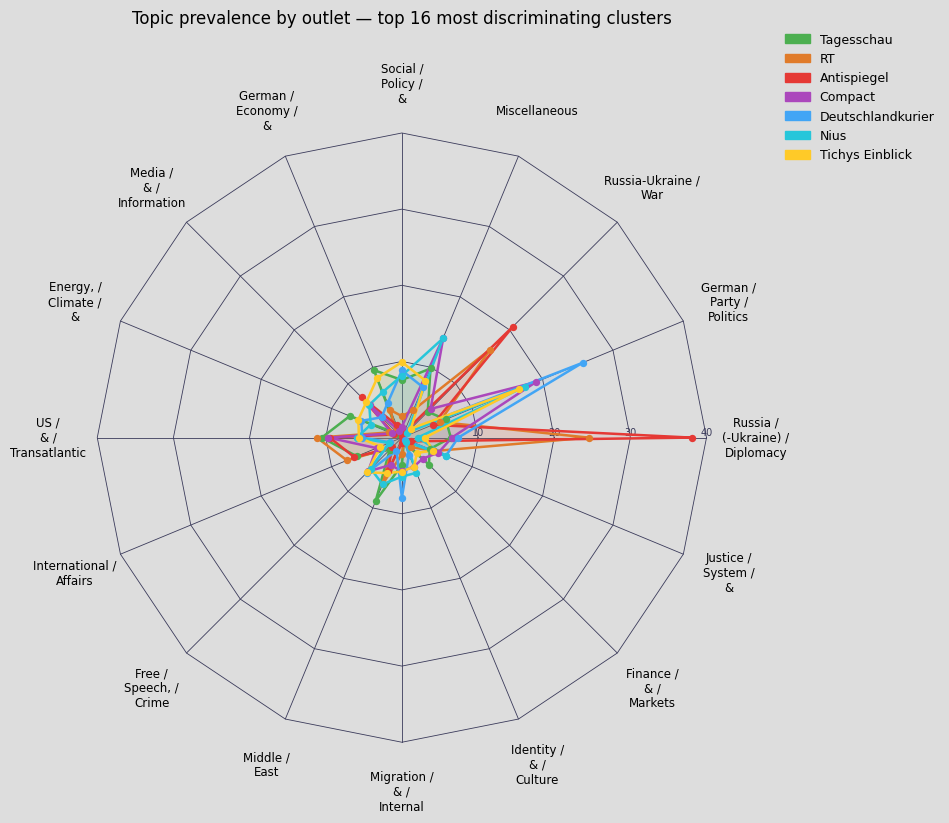

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/radar_cluster_prevalence.pdf


In [33]:
# ── Config ────────────────────────────────────────────────────────────────────
N_SPOKES   = 16      # how many cluster spokes to show (highest cross-outlet variance)
FIGSIZE    = (10, 10)
BG_COLOR   = "#DDDDDD"
GRID_COLOR = "#3A3A5A"
TEXT_COLOR = "black"

OUTLET_COLORS = {
    "Tagesschau":       "#4CAF50",
    "RT":               "#E07B2A",
    "Antispiegel":      "#E53935",
    "Compact":          "#AB47BC",
    "Deutschlandkurier":"#42A5F5",
    "Nius":             "#26C6DA",
    "Tichys Einblick":  "#FFCA28",
}

# ── Build wide pivot: outlet × cluster → share_pct ───────────────────────────
# Reuse cluster_shares if already computed, otherwise recompute
if "cluster_shares" not in dir():
    cluster_shares = compute_shares(df_raw, "Manual Cluster Label")

wide = (
    cluster_shares
    .pivot(index="outlet", columns="label", values="share_pct")
    .reindex(index=ALL_OUTLETS)
    .fillna(0.0)
)

# Select N_SPOKES clusters with highest variance across outlets
spoke_cols = wide.var(axis=0).nlargest(N_SPOKES).index.tolist()
wide_sel   = wide[spoke_cols]

# Short display labels (keep first 3 words to avoid overlong spokes)
def short(s, n=3):
    return " /\n".join(s.split()[:n])

labels     = [short(c) for c in spoke_cols]
n          = len(labels)
angles     = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles    += angles[:1]   # close polygon

# ── Draw ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=FIGSIZE, facecolor=BG_COLOR)
ax  = fig.add_subplot(111, polar=True, facecolor=BG_COLOR)

# Grid rings
max_val = wide_sel.to_numpy().max()
ring_steps = np.linspace(0, np.ceil(max_val / 2) * 2, 5)[1:]
for ring in ring_steps:
    ax.plot(angles, [ring] * (n + 1), color=GRID_COLOR, lw=0.6, zorder=1)
    ax.text(0, ring, f"{ring:.0f}", color=GRID_COLOR, fontsize=7,
            ha="center", va="bottom")

# Spoke lines
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, max_val * 1.05], color=GRID_COLOR, lw=0.6, zorder=1)

# One polygon per outlet
for outlet in ALL_OUTLETS:
    vals  = wide_sel.loc[outlet].tolist()
    vals += vals[:1]
    color = OUTLET_COLORS.get(outlet, "#AAAAAA")
    ax.plot(angles, vals, color=color, lw=1.8, zorder=3)
    ax.fill(angles, vals, color=color, alpha=0.08, zorder=2)
    # dots at vertices
    ax.scatter(angles[:-1], vals[:-1], color=color, s=28, zorder=4, linewidths=0)

# Spoke labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color=TEXT_COLOR, fontsize=8.5)
ax.tick_params(pad=14)

# Remove default polar grid/ticks
ax.set_yticks([])
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

# Legend
legend_patches = [
    mpatches.Patch(color=OUTLET_COLORS.get(o, "#AAAAAA"), label=o)
    for o in ALL_OUTLETS
]
ax.legend(
    handles=legend_patches,
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15),
    fontsize=9,
    frameon=False,
    labelcolor=TEXT_COLOR,
)

ax.set_title(
    f"Topic prevalence by outlet — top {N_SPOKES} most discriminating clusters",
    color=TEXT_COLOR, fontsize=12, pad=28,
)

fig.tight_layout()
out_path = FIG_BASE / "radar_cluster_prevalence.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=300, facecolor=BG_COLOR)
plt.show()
print("Saved:", out_path)

## Radar — outlet groups vs Tagesschau

Outlets pooled into three ideological groups; each group's prevalence = articles in cluster ÷ total group articles.

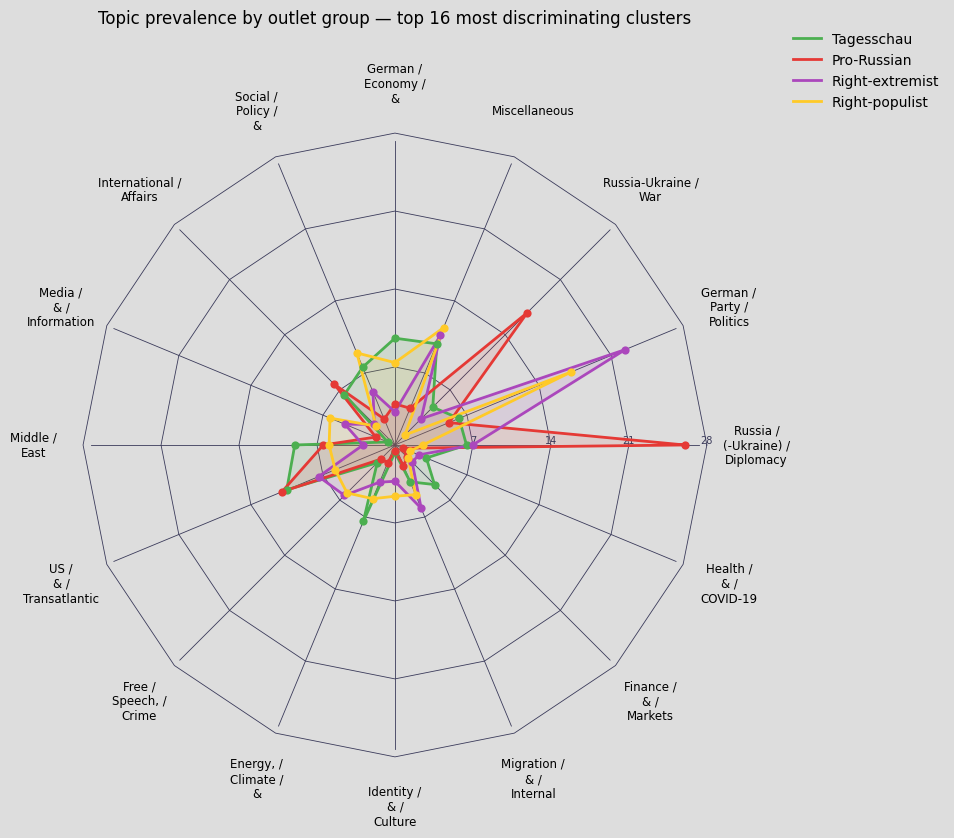

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/radar_group_prevalence.pdf


In [34]:
GROUPS = {
    "Tagesschau":      ["Tagesschau"],
    "Pro-Russian":     ["RT", "Antispiegel"],
    "Right-extremist": ["Deutschlandkurier", "Compact"],
    "Right-populist":  ["Tichys Einblick", "Nius"],
}
GROUP_COLORS = {
    "Tagesschau":      "#4CAF50",
    "Pro-Russian":     "#E53935",
    "Right-extremist": "#AB47BC",
    "Right-populist":  "#FFCA28",
}

# ── Compute group-level prevalence ────────────────────────────────────────────
label_col = "Manual Cluster Label"
label_universe = sorted(df_raw[label_col].unique())

group_shares = {}
for group, outlets in GROUPS.items():
    sub   = df_raw[df_raw["source"].isin(outlets)]
    total = len(sub)
    counts = sub[label_col].value_counts()
    group_shares[group] = {
        lbl: counts.get(lbl, 0) / total * 100
        for lbl in label_universe
    }

wide_g = pd.DataFrame(group_shares).T  # groups × clusters

# Select N_SPOKES spokes by highest variance across groups
spoke_cols_g = wide_g.var(axis=0).nlargest(N_SPOKES).index.tolist()
wide_g_sel   = wide_g[spoke_cols_g]

labels_g = [short(c) for c in spoke_cols_g]
n_g      = len(labels_g)
angles_g = np.linspace(0, 2 * np.pi, n_g, endpoint=False).tolist()
angles_g += angles_g[:1]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=FIGSIZE, facecolor=BG_COLOR)
ax  = fig.add_subplot(111, polar=True, facecolor=BG_COLOR)

max_val_g  = wide_g_sel.to_numpy().max()
ring_steps_g = np.linspace(0, np.ceil(max_val_g / 2) * 2, 5)[1:]
for ring in ring_steps_g:
    ax.plot(angles_g, [ring] * (n_g + 1), color=GRID_COLOR, lw=0.6, zorder=1)
    ax.text(0, ring, f"{ring:.0f}", color=GRID_COLOR, fontsize=7, ha="center", va="bottom")

for angle in angles_g[:-1]:
    ax.plot([angle, angle], [0, max_val_g * 1.05], color=GRID_COLOR, lw=0.6, zorder=1)

for group in GROUPS:
    vals  = wide_g_sel.loc[group].tolist() + [wide_g_sel.loc[group].tolist()[0]]
    color = GROUP_COLORS[group]
    ax.plot(angles_g, vals, color=color, lw=2.0, zorder=3, label=group)
    ax.fill(angles_g, vals, color=color, alpha=0.10, zorder=2)
    ax.scatter(angles_g[:-1], vals[:-1], color=color, s=35, zorder=4, linewidths=0)

ax.set_xticks(angles_g[:-1])
ax.set_xticklabels(labels_g, color=TEXT_COLOR, fontsize=8.5)
ax.tick_params(pad=14)
ax.set_yticks([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
          fontsize=10, frameon=False, labelcolor=TEXT_COLOR)
ax.set_title(f"Topic prevalence by outlet group — top {N_SPOKES} most discriminating clusters",
             color=TEXT_COLOR, fontsize=12, pad=28)

fig.tight_layout()
out_path = FIG_BASE / "radar_group_prevalence.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=300, facecolor=BG_COLOR)
plt.show()
print("Saved:", out_path)

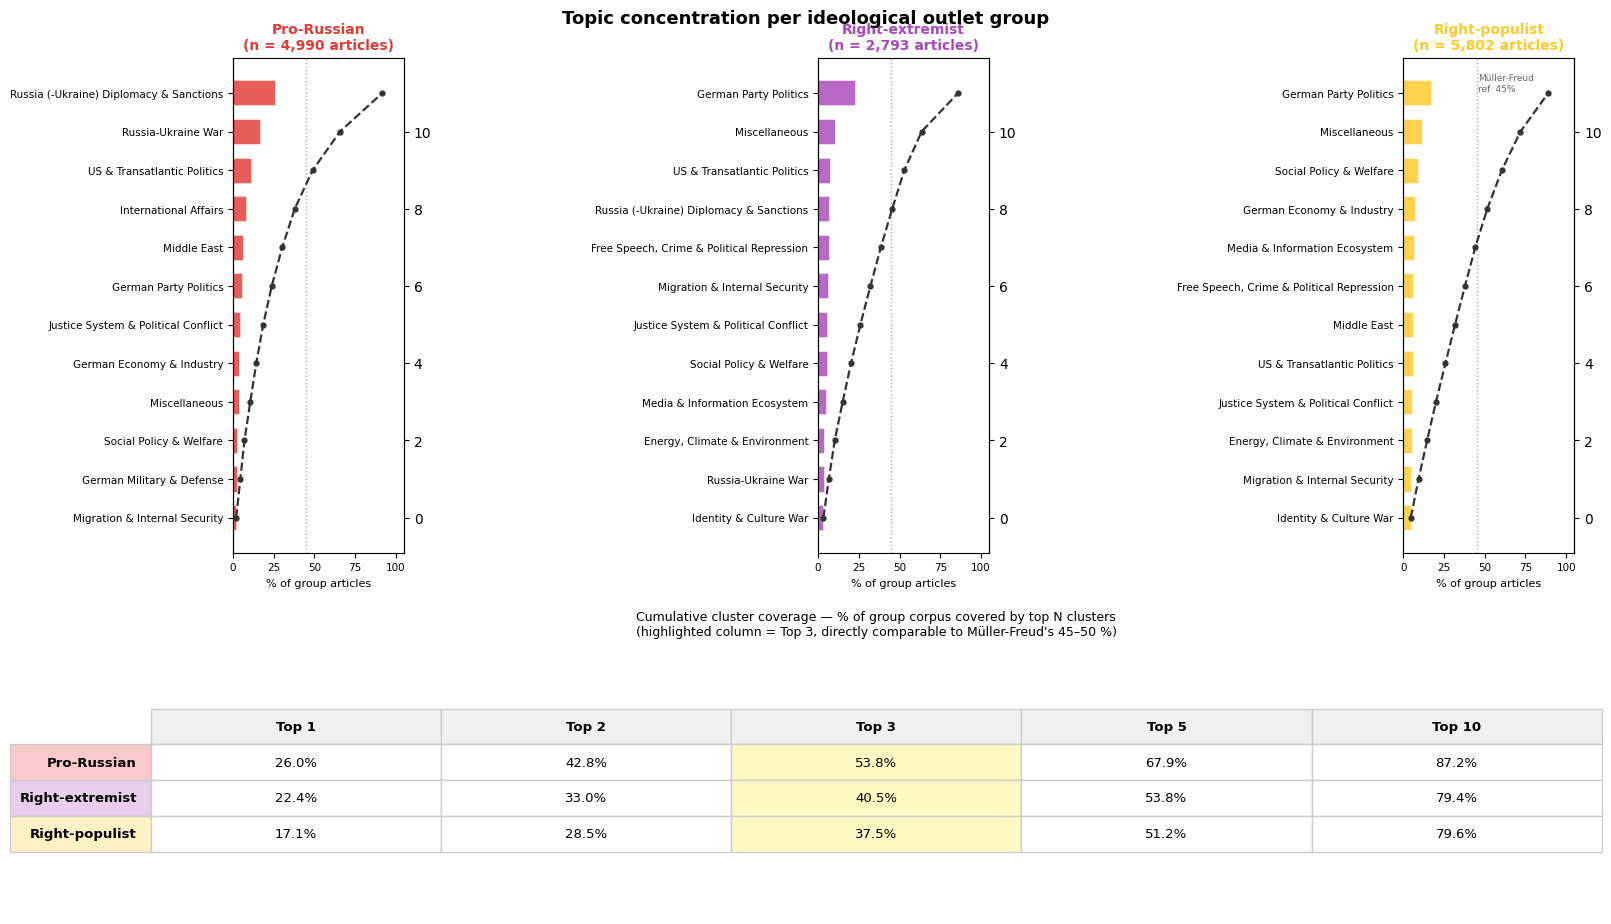

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/group_topic_concentration.pdf


In [ ]:
# ── Topic concentration by outlet group — comparable to Müller-Freud et al. ──
#
# Müller-Freud: top-3 clusters = 45–50 % of all articles in right-wing populist outlets.
# We replicate that metric at *cluster* level for each ideological group.

COMPARE_GROUPS = ["Pro-Russian", "Right-extremist", "Right-populist"]
TOP_N_BARS = 12      # clusters shown in bar chart
MULLER_REF = 45      # reference line from Müller-Freud (%)

# ── 1. Compute cluster shares per group (articles, not topic-model weight) ────
label_col = "Manual Cluster Label"
group_raw = {}
for group, outlets in GROUPS.items():
    sub = df_raw[df_raw["source"].isin(outlets)]
    total = len(sub)
    counts = sub[label_col].value_counts()
    group_raw[group] = {"total": total, "counts": counts}

def top_n_coverage(group: str, n: int) -> float:
    """% of group's articles covered by the n largest clusters."""
    counts = group_raw[group]["counts"]
    total  = group_raw[group]["total"]
    return counts.nlargest(n).sum() / total * 100

# ── 2. Two-panel figure ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9), constrained_layout=True)
outer = fig.add_gridspec(2, 1, height_ratios=[3, 1.4], hspace=0.08)

# ── Panel A: ranked bar + cumulative line, one column per group ───────────────
top_gs = outer[0].subgridspec(1, len(COMPARE_GROUPS), wspace=0.30)

for col_idx, group in enumerate(COMPARE_GROUPS):
    ax_bar = fig.add_subplot(top_gs[col_idx])
    ax_cum = ax_bar.twinx()

    counts = group_raw[group]["counts"]
    total  = group_raw[group]["total"]
    top    = (counts / total * 100).nlargest(TOP_N_BARS).sort_values()

    color  = GROUP_COLORS[group]
    bars   = ax_bar.barh(range(len(top)), top.values,
                         color=color, alpha=0.82, height=0.65,
                         edgecolor="white", linewidth=0.4)
    ax_bar.set_yticks(range(len(top)))
    ax_bar.set_yticklabels(top.index, fontsize=7.5)
    ax_bar.set_xlabel("% of group articles", fontsize=8)
    ax_bar.spines[["top"]].set_visible(False)
    ax_bar.tick_params(axis="x", labelsize=7.5)

    n_articles = group_raw[group]["total"]
    ax_bar.set_title(
        f"{group}\n(n = {n_articles:,} articles)",
        fontsize=10, fontweight="bold", color=color, pad=6
    )

    # Cumulative % line (ascending bars → cumsum from bottom)
    cum = np.cumsum(top.values)
    ax_cum.plot(cum, range(len(top)), color="#333", lw=1.6,
                linestyle="--", marker="o", markersize=3.5, zorder=5)
    ax_cum.set_ylim(ax_bar.get_ylim())
    ax_cum.set_xlim(0, 105)
    ax_cum.set_xlabel("Cumulative %", fontsize=7.5)
    ax_cum.xaxis.set_label_position("top")
    ax_cum.tick_params(axis="x", labelsize=7, top=True, labeltop=True,
                       bottom=False, labelbottom=False)
    ax_cum.spines[["bottom"]].set_visible(False)

    # Müller-Freud reference line at 45 %
    ax_cum.axvline(MULLER_REF, color="#888", lw=1.0, ls=":", alpha=0.7)
    if col_idx == len(COMPARE_GROUPS) - 1:
        ax_cum.text(MULLER_REF + 0.8, len(top) - 0.5,
                    f"Müller-Freud\nref. {MULLER_REF}%",
                    fontsize=6.5, color="#666", va="top")

# ── Panel B: concentration summary table ─────────────────────────────────────
ax_tbl = fig.add_subplot(outer[1])
ax_tbl.axis("off")

ns      = [1, 2, 3, 5, 10]
col_labels = [f"Top {n}" for n in ns]
row_labels = COMPARE_GROUPS
cell_text  = [
    [f"{top_n_coverage(g, n):.1f}%" for n in ns]
    for g in COMPARE_GROUPS
]

tbl = ax_tbl.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc="center",
    rowLoc="right",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.7)

# Colour row headers and shade top-3 column to match Müller-Freud comparison
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ccc")
    if r == 0:                          # column header
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold", fontsize=9.5)
    elif c == -1:                       # row label
        cell.set_facecolor(GROUP_COLORS.get(row_labels[r - 1], "#eee") + "44")
        cell.set_text_props(fontweight="bold")
    elif c == 2:                        # "Top 3" column — Müller-Freud comparison
        cell.set_facecolor("#FFF9C4")

ax_tbl.set_title(
    "Cumulative cluster coverage — % of group corpus covered by top N clusters\n"
    "(highlighted column = Top 3, directly comparable to Müller-Freud's 45–50 %)",
    fontsize=9, pad=8
)

fig.suptitle(
    "Topic concentration per ideological outlet group",
    fontsize=13, fontweight="bold", y=1.01
)


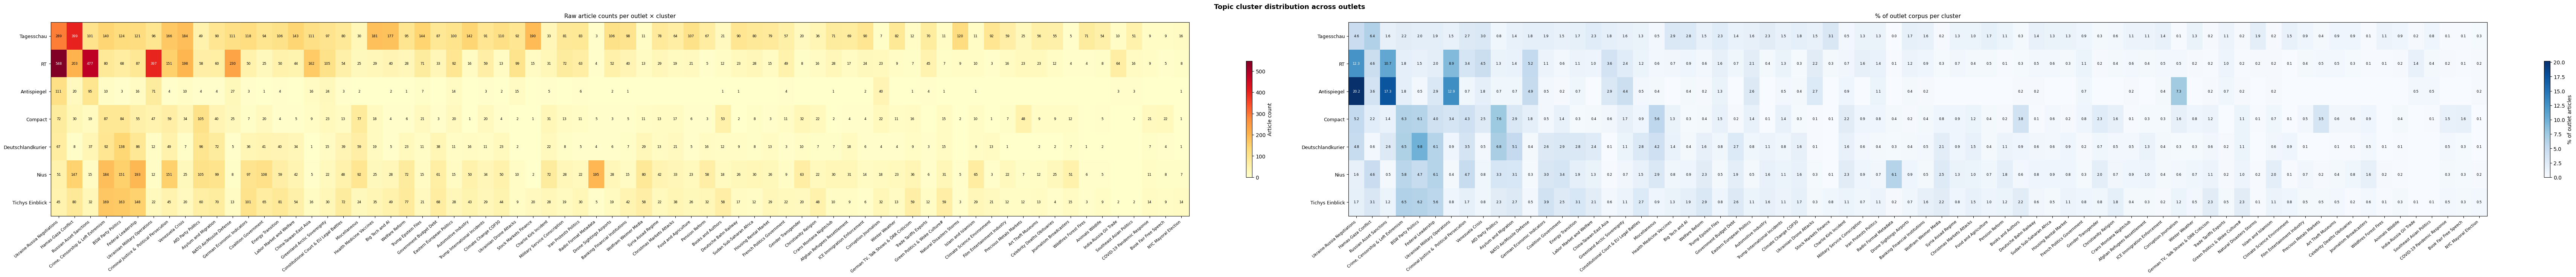

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/heatmap_counts_per_outlet.pdf


In [ ]:
# ── Heatmap: raw article counts per outlet × cluster ─────────────────────────
label_col = "Manual Topic Label"

pivot_counts = (
    df_raw.groupby(["source", label_col])
    .size()
    .unstack(fill_value=0)
    .reindex(index=ALL_OUTLETS)
)

# Row-normalise (% of outlet total) for a second heatmap shown side-by-side
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

# Sort clusters by total count descending
col_order = pivot_counts.sum(axis=0).sort_values(ascending=False).index
pivot_counts = pivot_counts[col_order]
pivot_pct    = pivot_pct[col_order]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(max(18, len(col_order) * 0.95), len(ALL_OUTLETS) * 0.75 + 2),
    constrained_layout=True,
)

for ax, data, fmt, title, cbar_label, cmap in [
    (ax1, pivot_counts, ".0f", "Raw article counts per outlet × cluster",
     "Article count", "YlOrRd"),
    (ax2, pivot_pct,    ".1f", "% of outlet corpus per cluster",
     "% of outlet articles", "Blues"),
]:
    im = ax.imshow(data.values, aspect="auto", cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.6)

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=40, ha="right", fontsize=7.5)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_title(title, fontsize=11, pad=8)

    # Annotate every cell
    vmax = data.values.max()
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data.iloc[r, c]
            if val == 0:
                continue
            brightness = val / vmax
            txt_color  = "white" if brightness > 0.55 else "black"
            ax.text(c, r, format(val, fmt),
                    ha="center", va="center",
                    fontsize=6.5, color=txt_color)

fig.suptitle("Topic cluster distribution across outlets", fontsize=13, fontweight="bold")



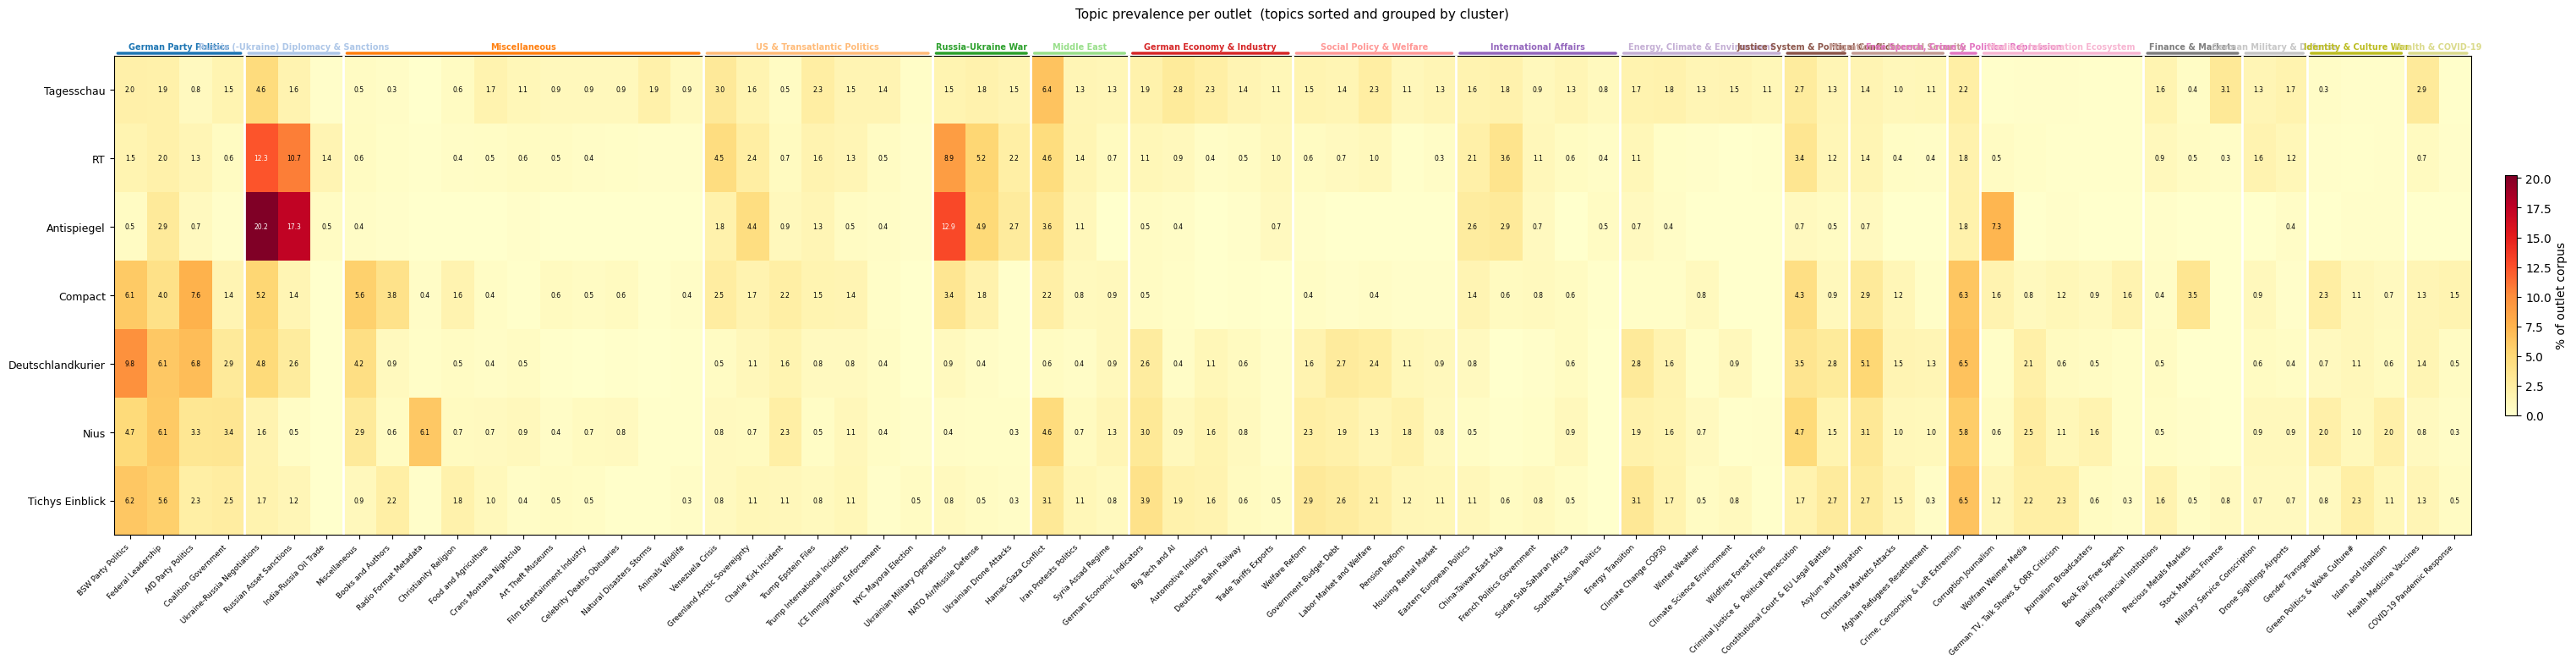

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/heatmap_topic_grouped_by_cluster.pdf


In [44]:
# ── Heatmap: topic-level counts, topics grouped by cluster ───────────────────

# Build outlet × topic count pivot
topic_pivot = (
    df_raw.groupby(["source", "Manual Topic Label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=ALL_OUTLETS)
)

# Row-normalise to % of outlet total
topic_pct = topic_pivot.div(topic_pivot.sum(axis=1), axis=0) * 100

# ── Sort topics: first by cluster, then by total count within cluster ─────────
topic_cluster_map = (
    df_raw[["Manual Topic Label", "Manual Cluster Label"]]
    .drop_duplicates()
    .set_index("Manual Topic Label")["Manual Cluster Label"]
)

# Sort clusters by their aggregate total (most prominent cluster first)
cluster_totals = (
    df_raw.groupby("Manual Cluster Label").size()
    .sort_values(ascending=False)
)
cluster_order = cluster_totals.index.tolist()

sorted_topics = []
cluster_boundaries = {}   # cluster_name → (start_row, end_row)
row = 0
for cluster in cluster_order:
    topics_in_cluster = (
        topic_cluster_map[topic_cluster_map == cluster].index
        .intersection(topic_pct.columns)
    )
    # Within cluster: sort by total count descending
    ordered = topic_pct[topics_in_cluster].sum(axis=0).sort_values(ascending=False).index.tolist()
    cluster_boundaries[cluster] = (row, row + len(ordered))
    sorted_topics.extend(ordered)
    row += len(ordered)

data = topic_pct[sorted_topics]     # outlets × sorted topics

# ── Plot ──────────────────────────────────────────────────────────────────────
n_topics  = len(sorted_topics)
n_outlets = len(ALL_OUTLETS)

fig, ax = plt.subplots(figsize=(n_topics * 0.38 + 3, n_outlets * 0.75 + 2.5),
                       constrained_layout=True)

im = ax.imshow(data.values, aspect="auto", cmap="YlOrRd", vmin=0)
plt.colorbar(im, ax=ax, label="% of outlet corpus", shrink=0.5, pad=0.01)

# Outlet labels (y-axis)
ax.set_yticks(range(n_outlets))
ax.set_yticklabels(data.index, fontsize=9)

# Topic labels (x-axis) — short: strip leading "Topic N — " prefix
def short_topic(t):
    return t.split("—")[-1].strip() if "—" in t else t

ax.set_xticks(range(n_topics))
ax.set_xticklabels([short_topic(t) for t in sorted_topics],
                   rotation=45, ha="right", fontsize=6.5)

# Annotate non-zero cells
vmax = data.values.max()
for r in range(n_outlets):
    for c in range(n_topics):
        val = data.iloc[r, c]
        if val < 0.3:
            continue
        txt_color = "white" if val / vmax > 0.6 else "black"
        ax.text(c, r, f"{val:.1f}", ha="center", va="center",
                fontsize=5.5, color=txt_color)

# ── Cluster dividers and labels ───────────────────────────────────────────────
cmap_clusters = plt.get_cmap("tab20")
cluster_colors = {c: cmap_clusters(i % 20) for i, c in enumerate(cluster_order)}

for i, cluster in enumerate(cluster_order):
    start, end = cluster_boundaries[cluster]
    mid = (start + end - 1) / 2

    # Vertical divider line after the last topic of this cluster
    if end < n_topics:
        ax.axvline(end - 0.5, color="white", lw=2.0, zorder=5)

    # Cluster label above the plot
    ax.annotate(
        cluster,
        xy=(mid, -0.5), xycoords=("data", "axes fraction"),
        xytext=(mid, 1.01), textcoords=("data", "axes fraction"),
        ha="center", va="bottom", fontsize=7, fontweight="bold",
        color=cluster_colors[cluster],
        annotation_clip=False,
        arrowprops=None,
    )

    # Coloured bracket line above x-axis labels
    ax.annotate("", xy=(start - 0.45, 1.005), xycoords=("data", "axes fraction"),
                xytext=(end - 0.55, 1.005), textcoords=("data", "axes fraction"),
                arrowprops=dict(arrowstyle="-", color=cluster_colors[cluster], lw=2.5),
                annotation_clip=False)

ax.set_title(
    "Topic prevalence per outlet  (topics sorted and grouped by cluster)",
    fontsize=11, pad=32
)

out_path = FIG_BASE / "heatmap_topic_grouped_by_cluster.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()
print("Saved:", out_path)


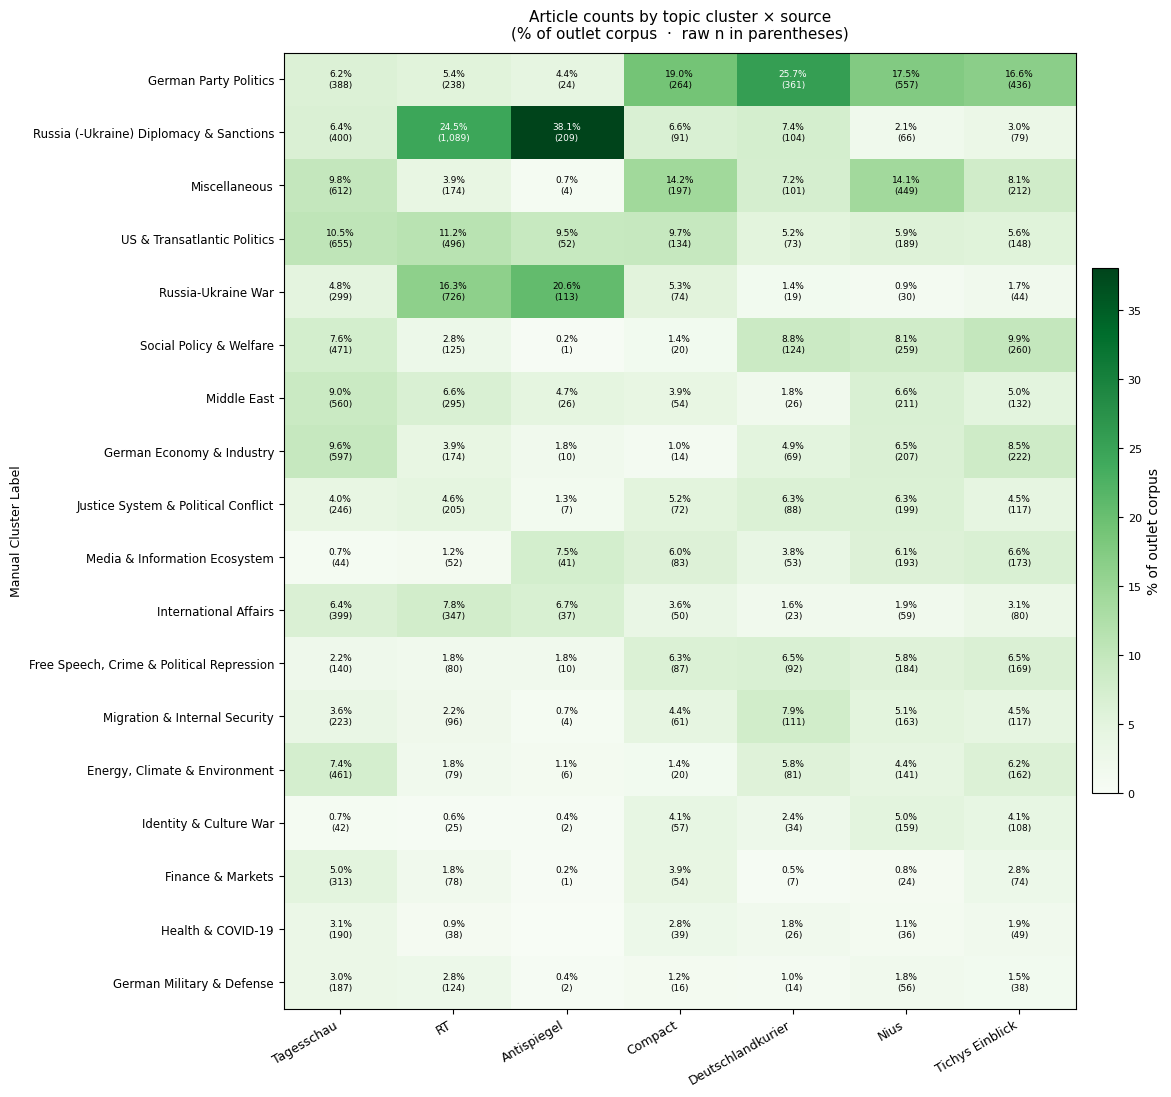

Saved: /Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/figures/prevalence_scatter/heatmap_cluster_relative.pdf


In [45]:
# ── Heatmap: cluster prevalence relative to outlet corpus size ────────────────

label_col = "Manual Cluster Label"

counts = (
    df_raw.groupby(["source", label_col])
    .size()
    .unstack(fill_value=0)
    .reindex(index=ALL_OUTLETS)
)

# Normalise each outlet row to % of that outlet's total articles
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# Sort clusters by mean prevalence across outlets (descending → most universal on top)
cluster_order = pct.mean(axis=0).sort_values(ascending=False).index
pct    = pct[cluster_order]
counts = counts[cluster_order]

n_clusters = len(cluster_order)
n_outlets  = len(ALL_OUTLETS)

fig, ax = plt.subplots(
    figsize=(n_outlets * 1.3 + 2.5, n_clusters * 0.52 + 1.5),
    constrained_layout=True,
)

im = ax.imshow(pct.T.values, aspect="auto", cmap="Greens", vmin=0)
cbar = plt.colorbar(im, ax=ax, label="% of outlet corpus", shrink=0.55, pad=0.02)
cbar.ax.tick_params(labelsize=8)

# Axes
ax.set_xticks(range(n_outlets))
ax.set_xticklabels(pct.index, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(n_clusters))
ax.set_yticklabels(cluster_order, fontsize=8.5)
ax.set_ylabel("Manual Cluster Label", fontsize=9)

# Cell annotations: show % (and raw n in smaller text)
vmax = pct.values.max()
for r_out, outlet in enumerate(pct.index):
    for r_cl, cluster in enumerate(cluster_order):
        pct_val   = pct.loc[outlet, cluster]
        count_val = int(counts.loc[outlet, cluster])
        if pct_val < 0.1:
            continue
        brightness = pct_val / vmax
        txt_color  = "white" if brightness > 0.62 else "black"
        ax.text(r_out, r_cl,
                f"{pct_val:.1f}%\n({count_val:,})",
                ha="center", va="center",
                fontsize=6.5, color=txt_color, linespacing=1.3)

ax.set_title(
    "Article counts by topic cluster × source\n(% of outlet corpus  ·  raw n in parentheses)",
    fontsize=11, pad=10,
)

out_path = FIG_BASE / "heatmap_cluster_relative.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()
print("Saved:", out_path)
